# Notebook 12 — End-to-End Deterministic Pipeline Baseline & Error Attribution

Execução sem uso de oracle: texto → Detector V2 → Parser V1 → Resolver V1. O gold é usado somente para avaliação posterior por IoU >= 0,5.

In [1]:
from __future__ import annotations
from collections import Counter
from pathlib import Path
import hashlib
import re
import time

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from bracis_jusbrasil.cases import build_case_index
from bracis_jusbrasil.citations import CitationCandidate, CitationDetector, CitationParser, CitationResolver
from bracis_jusbrasil.database import connect_database, get_database_path

pd.set_option("display.max_colwidth", 100)
DATASET_DIR = next(path for path in (Path("material_desafio_jusbrasil_bracis"), Path("../material_desafio_jusbrasil_bracis")) if path.is_dir())
DB_PATH, GOLD_PATH, TEXT_DIR = DATASET_DIR / "desafio1_bracis.db", DATASET_DIR / "goldenset.xlsx", DATASET_DIR / "txt"
EXPECTED_HASH = "d759681be82ee00f383b49a5c76c42dd475564e042272e00730252468dcb6e71"

assert hashlib.sha256(DB_PATH.read_bytes()).hexdigest() == EXPECTED_HASH
texts = {path.stem: path.read_text(encoding="utf-8") for path in sorted(TEXT_DIR.glob("*.txt"))}
gold = pd.read_excel(GOLD_PATH, sheet_name="goldenset", engine="openpyxl").reset_index(names="gold_idx")
gold["nivel"] = "N" + gold.nivel.astype(str).str.removeprefix("N")
assert len(texts) == 26 and len(gold) == 225
assert gold.classificacao.value_counts().to_dict() == {"real": 96, "incompleta": 65, "inventada": 64}
assert gold.tipo.value_counts().to_dict() == {"jurisprudencia": 186, "lei": 39}
assert all(texts[row.documento_id][row.inicio:row.fim] == row.trecho.replace("\\n", "\n") for row in gold.itertuples())
with connect_database(get_database_path(), read_only=True) as connection:
    assert connection.execute("PRAGMA integrity_check").fetchone()[0] == "ok"

CNJ = re.compile(r"\b\d{3,7}\s*-\s*\d{2}\s*[.]\s*\d{4}\s*[.]\s*\d\s*[.]\s*\d{2}\s*[.]\s*\d{4}\b")
SUMULA = re.compile(r"\bS[ÚU]MULA(?:\s+VINCULANTE)?\s*(?:N[ºO.]?\s*)?\d+", re.I)
ARTICLE = re.compile(r"\b(?:art(?:igo)?s?[.]?\s*)\d+", re.I)
DIPLOMA = re.compile(r"\b(?:Constituiç[aã]o(?: Federal)?|C[oó]digo|Lei(?: Complementar)?\s*(?:n[ºo.]?\s*)?\d+|CLT|CPC|CPP|CC|CDC|CPM)\b", re.I)
PROCESS = re.compile(r"\b(?:AREsp|REsp|AgInt|AgRg|EDcl|HC|Rcl|ADI|ADPF|RE|AI|MS|RR|AIRR|AP|RO|Agravo|Recurso Especial|Recurso Extraordinário|Habeas Corpus|Reclamação)\b", re.I)
COURT = re.compile(r"\b(?:STF|STJ|TSE|TST|STM|Supremo Tribunal Federal|Superior Tribunal de Justiça|Tribunal Superior Eleitoral|Tribunal Superior do Trabalho|Superior Tribunal Militar)\b", re.I)
YEAR, RELATOR = re.compile(r"\b(?:19\d{2}|20\d{2})\b"), re.compile(r"\b(?:Rel\.?|Relator(?:a)?)\s*(?:Min\.?|Ministra|Ministro|Des\.?)?\s*[A-Z]", re.I)

def family_for(text, citation_type):
    if citation_type == "lei":
        return "lei_dispositivo_com_diploma" if ARTICLE.search(text) and DIPLOMA.search(text) else "lei_dispositivo_sem_diploma" if ARTICLE.search(text) else "lei_referencia_geral"
    if SUMULA.search(text): return "sumula_numerada"
    if CNJ.search(text): return "processo_cnj"
    if PROCESS.search(text) and re.search(r"\d", text): return "processo_ou_recurso_numerado"
    if COURT.search(text) and (YEAR.search(text) or RELATOR.search(text)): return "jurisprudencia_tribunal_contextual"
    return "jurisprudencia_referencia_geral"

def iou(a, b, c, d):
    return max(0, min(b, d) - max(a, c)) / (max(b, d) - min(a, c)) if max(b, d) > min(a, c) else 0.0

def run_pipeline():
    detector, parser = CitationDetector(), CitationParser()
    started, rows = time.perf_counter(), []
    with connect_database(get_database_path(), read_only=True) as connection:
        resolver = CitationResolver(case_index=build_case_index(connection), connection=connection)
        for document_id, text in texts.items():
            for candidate in detector.detect(text):
                parsed = parser.parse(candidate)
                result = resolver.resolve(parsed)
                rows.append({"documento_id": document_id, "start": candidate.start, "end": candidate.end, "text": candidate.text, "rule": candidate.rule, "candidate_family": candidate.family, "candidate_tipo": parsed.tipo, "candidate": candidate, "parsed": parsed, "result": result})
    return pd.DataFrame(rows).reset_index(names="pred_idx"), time.perf_counter() - started

def greedy_match():
    pairs = []
    for document_id, group in gold.groupby("documento_id"):
        predicted = predictions.loc[predictions.documento_id.eq(document_id)]
        for g in group.itertuples():
            for p in predicted.itertuples():
                value = iou(g.inicio, g.fim, p.start, p.end)
                if value >= 0.5:
                    pairs.append((value, g.gold_idx, p.pred_idx, g.inicio == p.start and g.fim == p.end))
    used_gold, used_predictions, selected = set(), set(), []
    for value, gold_idx, pred_idx, exact in sorted(pairs, key=lambda x: (-x[0], x[1], x[2])):
        if gold_idx not in used_gold and pred_idx not in used_predictions:
            selected.append((gold_idx, pred_idx, value, exact))
            used_gold.add(gold_idx); used_predictions.add(pred_idx)
    return pd.DataFrame(selected, columns=["gold_idx", "pred_idx", "iou", "exact"])

predictions, elapsed_seconds = run_pipeline()
matches = greedy_match()
assert (len(predictions), len(matches), len(predictions) - len(matches), len(gold) - len(matches), int(matches.exact.sum())) == (206, 117, 89, 108, 25)
print("Detector reproduzido: predictions=206, TP=117, FP=89, FN=108, exact=25.")
print("Pipeline: {:.3f}s total; {:.4f}s por documento.".format(elapsed_seconds, elapsed_seconds / 26))

Detector reproduzido: predictions=206, TP=117, FP=89, FN=108, exact=25.
Pipeline: 0.908s total; 0.0349s por documento.


In [2]:
FIELDS = {
    "processo_ou_recurso_numerado": ("numero_normalizado", "classe_raw", "uf"),
    "processo_cnj": ("numero_normalizado",),
    "sumula_numerada": ("sumula_numero", "tribunal"),
    "lei_dispositivo_com_diploma": ("artigo", "diploma_normalizado", "law_number"),
    "lei_dispositivo_sem_diploma": ("artigo",),
    "lei_referencia_geral": ("diploma_normalizado",),
    "jurisprudencia_tribunal_contextual": ("tribunal", "relator_raw", "ano"),
    "jurisprudencia_referencia_geral": (),
}

def field_value(parsed, field):
    return parsed.tribunal if field == "tribunal" else parsed.data.get(field)

def parser_equivalent(detected, oracle, family):
    return detected.family == oracle.family and all(
        field_value(detected, key) == field_value(oracle, key)
        for key in FIELDS[family]
    )

def value_visible(oracle, text, family):
    digits = re.sub(r"\D", "", text)
    for field in FIELDS[family]:
        value = field_value(oracle, field)
        if not value:
            continue
        if field in {"numero_normalizado", "sumula_numero", "law_number", "artigo"} and str(value) not in digits:
            return False
        if field == "tribunal" and not COURT.search(text):
            return False
        if field == "classe_raw" and not re.search(re.escape(str(value)), text, re.I):
            return False
        if field == "uf" and not re.search(r"(?<![A-Z])" + re.escape(str(value)) + r"(?![A-Z])", text):
            return False
        if field in {"diploma_normalizado", "relator_raw", "ano"} and str(value).upper() not in text.upper():
            return False
    return True

match_by_gold = {row.gold_idx: (row.pred_idx, row.iou, row.exact) for row in matches.itertuples()}
pred_by_idx = predictions.set_index("pred_idx")
parser = CitationParser()
with connect_database(get_database_path(), read_only=True) as connection:
    resolver = CitationResolver(case_index=build_case_index(connection), connection=connection)
    rows, oracle_results = [], []
    for g in gold.itertuples():
        gold_text = texts[g.documento_id][g.inicio:g.fim]
        gold_family = family_for(gold_text, g.tipo)
        oracle_parsed = parser.parse(CitationCandidate(0, len(gold_text), gold_text, "oracle", gold_family))
        oracle_result = resolver.resolve(oracle_parsed)
        item = g._asdict()
        item.update(gold_text=gold_text, gold_family=gold_family, oracle_parsed=oracle_parsed, oracle_result=oracle_result)
        matched = match_by_gold.get(g.gold_idx)
        if matched is None:
            overlaps = [iou(g.inicio, g.fim, p.start, p.end) for p in predictions.loc[predictions.documento_id.eq(g.documento_id)].itertuples()]
            item.update(detector_status="unmatched", iou=0.0, exact_span=False, candidate_text=None, candidate_family=None, candidate_tipo=None, parsed=None, parsed_data={}, parser_equivalent=False, resolver_status=None, resolved_id=None, candidate_ids=(), strategy=None, reason=None, final_predicted_class="missing", final_id_canonico=None, first_blocker="detector_boundary_failure" if max(overlaps, default=0) > 0 else "detector_miss")
        else:
            pred_idx, match_iou, exact = matched
            p = pred_by_idx.loc[pred_idx]
            parsed, result = p.parsed, p.result
            parse_equivalent = parser_equivalent(parsed, oracle_parsed, gold_family)
            correct = g.classificacao == "real" and result.status == "resolved" and result.id_canonico == g.id_canonico
            wrong = result.status == "resolved" and not correct
            if correct:
                blocker = "resolved_correct"
            elif wrong:
                blocker = "resolved_wrong"
            elif parsed.family != gold_family:
                blocker = "detector_family_mismatch"
            elif not parse_equivalent:
                blocker = "parser_gap" if value_visible(oracle_parsed, p.text, gold_family) else "detector_boundary_failure"
            else:
                blocker = "resolver_" + result.status
            predicted_class = {"resolved": "real", "no_match": "inventada", "ambiguous": "incompleta", "insufficient": "incompleta"}[result.status]
            item.update(detector_status="matched", iou=match_iou, exact_span=exact, candidate_text=p.text, candidate_family=p.candidate_family, candidate_tipo=p.candidate_tipo, parsed=parsed, parsed_data=dict(parsed.data), parser_equivalent=parse_equivalent, resolver_status=result.status, resolved_id=result.id_canonico, candidate_ids=result.candidate_ids, strategy=result.strategy, reason=result.reason, final_predicted_class=predicted_class, final_id_canonico=result.id_canonico if result.status == "resolved" else None, first_blocker=blocker)
        rows.append(item)
        oracle_results.append(oracle_result)
tracking = pd.DataFrame(rows)

assert Counter(result.status for result, g in zip(oracle_results, gold.itertuples()) if g.classificacao == "real") == Counter({"resolved": 41, "no_match": 2, "ambiguous": 1, "insufficient": 52})
assert Counter(result.status for result, g in zip(oracle_results, gold.itertuples()) if g.classificacao == "inventada") == Counter({"no_match": 36, "insufficient": 28})
assert Counter(result.status for result, g in zip(oracle_results, gold.itertuples()) if g.classificacao == "incompleta") == Counter({"insufficient": 65})

matched_predictions = set(matches.pred_idx)
fps = predictions.loc[~predictions.pred_idx.isin(matched_predictions)].copy()
fps["resolver_status"] = fps.result.map(lambda result: result.status)
fps["resolved_id"] = fps.result.map(lambda result: result.id_canonico)
fps["strategy"] = fps.result.map(lambda result: result.strategy)

def fp_label(row):
    related = gold.loc[gold.documento_id.eq(row.documento_id)].copy()
    related["iou"] = related.apply(lambda g: iou(g.inicio, g.fim, row.start, row.end), axis=1)
    real = related.loc[(related.iou > 0) & related.classificacao.eq("real")]
    if not real.empty and row.resolved_id in set(real.id_canonico.dropna().astype(int)):
        return "resolved_id_matches_overlapping_real_below_threshold"
    return "no_gold_overlap" if related.loc[related.iou > 0].empty else "overlaps_gold_below_threshold"

fps["audit_label"] = fps.apply(fp_label, axis=1)
print("Oracle Resolver V1 reproduzido: real 41/2/1/52; inventada 0/36/0/28; incompleta 0/0/0/65.")

Oracle Resolver V1 reproduzido: real 41/2/1/52; inventada 0/36/0/28; incompleta 0/0/0/65.


,count
predictions,206
TP,117
FP,89
FN,108
exact,25


,stage,count,% previous,% total,% of 96
0,gold real,96,100.0,100.0,100.0
1,detector matched,61,63.5,63.5,63.5
2,parser identity sufficient,31,50.8,32.3,32.3
3,safe strategy applicable,31,100.0,32.3,32.3
4,correctly resolved,27,87.1,28.1,28.1


,stage,count,% previous,% total
0,gold inventada,64,100.0,100.0
1,detector matched,44,68.8,68.8
2,parser identity sufficient,25,56.8,39.1
3,safe strategy applicable,25,100.0,39.1
4,resolved,0,0.0,0.0


,stage,count,% previous,% total
0,gold incompleta,65,100.0,100.0
1,detector matched,12,18.5,18.5
2,parser identity sufficient,0,0.0,0.0
3,safe strategy applicable,0,NaN,0.0
4,resolved,0,NaN,0.0


resolver_status,resolved,no_match,ambiguous,insufficient,missing
classificacao,,,,,
real,27,3,1,30,35
inventada,0,25,0,19,20
incompleta,0,0,0,12,53


...

,count,%
first_blocker,,
detector_miss,19,19.8
detector_boundary_failure,21,21.9
detector_family_mismatch,5,5.2
parser_gap,0,0.0
resolver_insufficient,22,22.9
resolver_ambiguous,1,1.0
resolver_no_match,1,1.0
resolved_wrong,0,0.0
resolved_correct,27,28.1


,count
first_blocker,
detector_miss,67
detector_boundary_failure,71
detector_family_mismatch,5
parser_gap,0
resolver_insufficient,49
resolver_ambiguous,1
resolver_no_match,5
resolved_wrong,0
resolved_correct,27


first_blocker,detector_miss,detector_boundary_failure,detector_family_mismatch,parser_gap,resolver_insufficient,resolver_ambiguous,resolver_no_match,resolved_wrong,resolved_correct
gold_family,,,,,,,,,
jurisprudencia_referencia_geral,34,0,0,0,12,0,0,0,0
jurisprudencia_tribunal_contextual,4,16,0,0,0,0,0,0,0
lei_dispositivo_com_diploma,0,11,1,0,15,0,0,0,0
lei_dispositivo_sem_diploma,0,1,0,0,0,0,0,0,0
lei_referencia_geral,11,0,0,0,0,0,0,0,0
processo_cnj,0,2,4,0,19,0,0,0,0
processo_ou_recurso_numerado,18,34,0,0,0,1,5,0,27
sumula_numerada,0,7,0,0,3,0,0,0,0


,gold,detector_matched,parser_equivalent,correct_id
nivel,,,,
N1,116,72,30,18
N2,109,45,29,9


ID accuracy over all real: 27/96 = 28.1%
ID accuracy given resolved real: 27/27 = 100.0%
Critical E2E: {'wrong_unique_real': 0, 'false_real_inventada': 0, 'false_real_incompleta': 0, 'resolved_from_detector_fp': 5}


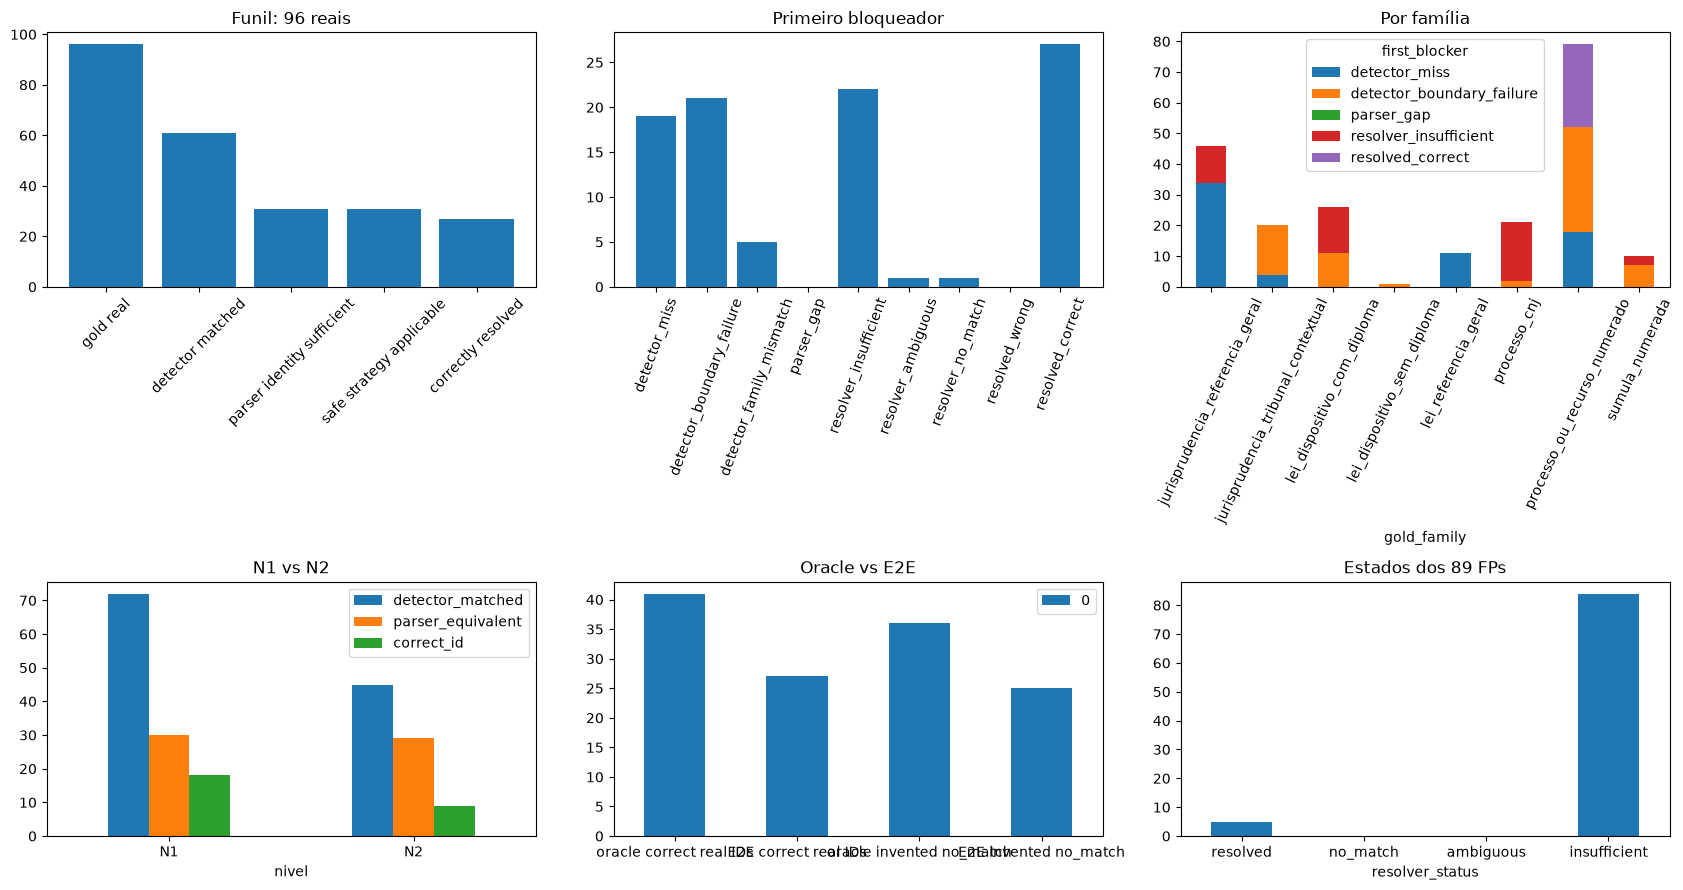

,matched,parser_equivalent_rate,resolved_correct
iou_band,,,
0.50–0.59,14,0.285714,0
0.60–0.79,43,0.534884,7
0.80–0.99,35,0.200000,18
1.00,25,1.000000,2


In [3]:
status_order, class_order = ["resolved", "no_match", "ambiguous", "insufficient"], ["real", "inventada", "incompleta"]
real = tracking.loc[tracking.classificacao.eq("real")]

def funnel(frame, total_label):
    result = pd.DataFrame([
        (total_label, len(frame)),
        ("detector matched", int((frame.detector_status == "matched").sum())),
        ("parser identity sufficient", int(frame.strategy.notna().sum())),
        ("safe strategy applicable", int(frame.strategy.notna().sum())),
        ("resolved", int((frame.resolver_status == "resolved").sum())),
    ], columns=["stage", "count"])
    result["% previous"] = result["count"].div(result["count"].shift(fill_value=len(frame))).mul(100).round(1)
    result["% total"] = result["count"].div(len(frame)).mul(100).round(1)
    return result

real_funnel = funnel(real, "gold real")
invented_funnel = funnel(tracking[tracking.classificacao == "inventada"], "gold inventada")
incomplete_funnel = funnel(tracking[tracking.classificacao == "incompleta"], "gold incompleta")
correct_ids = int(((real.resolver_status == "resolved") & (real.resolved_id == real.id_canonico)).sum())
real_funnel.loc[real_funnel.stage == "resolved", ["stage", "count"]] = ["correctly resolved", correct_ids]
real_funnel["% previous"] = real_funnel["count"].div(real_funnel["count"].shift(fill_value=96)).mul(100).round(1)
real_funnel["% of 96"] = real_funnel["count"].div(96).mul(100).round(1)

e2e_matrix = pd.crosstab(tracking.classificacao, tracking.resolver_status).reindex(index=class_order, columns=status_order, fill_value=0)
e2e_matrix["missing"] = tracking.resolver_status.isna().groupby(tracking.classificacao).sum().reindex(class_order, fill_value=0)
classification_confusion = pd.crosstab(tracking.classificacao, tracking.final_predicted_class).reindex(index=class_order, columns=["real", "inventada", "incompleta", "missing"], fill_value=0)
parser_impact = tracking[tracking.detector_status == "matched"].groupby("gold_family").agg(matched=("gold_idx", "size"), parser_equivalent=("parser_equivalent", "sum"), parser_degraded=("parser_equivalent", lambda x: int((~x).sum())))
boundary = tracking[tracking.detector_status == "matched"].copy()
boundary["quality"] = boundary.apply(lambda r: "exact" if r.exact_span else "non-exact safe" if r.parser_equivalent else "non-exact damaging", axis=1)
boundary_impact = boundary.groupby("quality").agg(matched=("gold_idx", "size"), parser_ok=("parser_equivalent", "sum"), resolved_correct=("first_blocker", lambda x: int((x == "resolved_correct").sum()))).reindex(["exact", "non-exact safe", "non-exact damaging"], fill_value=0)
order = ["detector_miss", "detector_boundary_failure", "detector_family_mismatch", "parser_gap", "resolver_insufficient", "resolver_ambiguous", "resolver_no_match", "resolved_wrong", "resolved_correct"]
real_attribution = real.first_blocker.value_counts().reindex(order, fill_value=0).to_frame("count")
real_attribution["%"] = real_attribution["count"].div(96).mul(100).round(1)
global_attribution = tracking.first_blocker.value_counts().reindex(order, fill_value=0).to_frame("count")
family_attribution = pd.crosstab(tracking.gold_family, tracking.first_blocker).reindex(columns=order, fill_value=0)
levels = tracking.groupby("nivel").agg(gold=("gold_idx", "size"), detector_matched=("detector_status", lambda x: int((x == "matched").sum())), parser_equivalent=("parser_equivalent", "sum"), correct_id=("first_blocker", lambda x: int((x == "resolved_correct").sum())))
oracle_e2e = pd.DataFrame({"oracle correct real IDs": [41], "E2E correct real IDs": [correct_ids], "oracle invented no_match": [36], "E2E invented no_match": [int(((tracking.classificacao == "inventada") & (tracking.resolver_status == "no_match")).sum())]})

display(pd.DataFrame({"count": [206, 117, 89, 108, 25]}, index=["predictions", "TP", "FP", "FN", "exact"]))
display(real_funnel); display(invented_funnel); display(incomplete_funnel)
display(e2e_matrix); display(classification_confusion)
display(parser_impact); display(boundary_impact)
display(real_attribution); display(global_attribution); display(family_attribution); display(levels)
print("ID accuracy over all real: {}/96 = {:.1%}".format(correct_ids, correct_ids / 96))
print("ID accuracy given resolved real: {}/{} = {:.1%}".format(correct_ids, int((real.resolver_status == "resolved").sum()), correct_ids / int((real.resolver_status == "resolved").sum())))
print("Critical E2E:", {"wrong_unique_real": int(((real.resolver_status == "resolved") & (real.resolved_id != real.id_canonico)).sum()), "false_real_inventada": int(((tracking.classificacao == "inventada") & (tracking.resolver_status == "resolved")).sum()), "false_real_incompleta": int(((tracking.classificacao == "incompleta") & (tracking.resolver_status == "resolved")).sum()), "resolved_from_detector_fp": int((fps.resolver_status == "resolved").sum())})

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes[0, 0].bar(real_funnel.stage, real_funnel["count"]); axes[0, 0].set_title("Funil: 96 reais"); axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 1].bar(real_attribution.index, real_attribution["count"]); axes[0, 1].set_title("Primeiro bloqueador"); axes[0, 1].tick_params(axis="x", rotation=70)
family_attribution[["detector_miss", "detector_boundary_failure", "parser_gap", "resolver_insufficient", "resolved_correct"]].plot(kind="bar", stacked=True, ax=axes[0, 2]); axes[0, 2].set_title("Por família"); axes[0, 2].tick_params(axis="x", rotation=65)
levels[["detector_matched", "parser_equivalent", "correct_id"]].plot(kind="bar", ax=axes[1, 0]); axes[1, 0].set_title("N1 vs N2"); axes[1, 0].tick_params(axis="x", rotation=0)
oracle_e2e.T.plot(kind="bar", ax=axes[1, 1]); axes[1, 1].set_title("Oracle vs E2E"); axes[1, 1].tick_params(axis="x", rotation=0)
fps.resolver_status.value_counts().reindex(status_order, fill_value=0).plot(kind="bar", ax=axes[1, 2]); axes[1, 2].set_title("Estados dos 89 FPs"); axes[1, 2].tick_params(axis="x", rotation=0)
fig.tight_layout(); plt.show()

iou_table = boundary.assign(iou_band=pd.cut(boundary.iou, [0.49, 0.59, 0.79, 0.99, 1.0], labels=["0.50–0.59", "0.60–0.79", "0.80–0.99", "1.00"])).groupby("iou_band", observed=False).agg(matched=("gold_idx", "size"), parser_equivalent_rate=("parser_equivalent", "mean"), resolved_correct=("first_blocker", lambda x: int((x == "resolved_correct").sum())))
display(iou_table)

In [4]:
fp_resolved_audit = fps.loc[fps.resolver_status == "resolved", ["documento_id", "start", "end", "text", "candidate_family", "resolved_id", "strategy", "audit_label"]]
real_no_match = tracking.loc[(tracking.classificacao == "real") & (tracking.resolver_status == "no_match"), ["documento_id", "gold_text", "candidate_text", "gold_family", "parsed_data", "reason"]]
ambiguous = tracking.loc[tracking.resolver_status == "ambiguous", ["documento_id", "gold_text", "candidate_text", "gold_family", "candidate_ids", "reason"]]
parser_gaps = tracking.loc[tracking.first_blocker == "parser_gap", ["documento_id", "gold_text", "candidate_text", "gold_family", "parsed_data"]]
experimental_output = predictions.assign(
    inicio=predictions.start,
    fim=predictions.end,
    trecho=predictions.text,
    tipo=predictions.candidate_tipo,
    classificacao_experimental=predictions.result.map(lambda r: {"resolved": "real", "no_match": "inventada", "ambiguous": "incompleta", "insufficient": "incompleta"}[r.status]),
    id_canonico=predictions.result.map(lambda r: r.id_canonico if r.status == "resolved" else None),
)
duplicates = experimental_output[experimental_output.id_canonico.notna()].groupby(["documento_id", "id_canonico"]).size().loc[lambda values: values > 1].to_frame("candidate_count")

display(fps.resolver_status.value_counts().reindex(status_order, fill_value=0).to_frame("detector FP count"))
display(fp_resolved_audit)
display(real_no_match)
display(ambiguous)
display(parser_gaps)
display(duplicates)
display(experimental_output[["documento_id", "inicio", "fim", "trecho", "tipo", "classificacao_experimental", "id_canonico"]].head(12))

snapshots = []
for _ in range(3):
    snapshot, _ = run_pipeline()
    snapshots.append(tuple((row.documento_id, row.start, row.end, row.candidate, row.parsed, row.result) for row in snapshot.itertuples()))
assert snapshots[0] == snapshots[1] == snapshots[2]

oracle_correct_detected = int(sum(
    row.classificacao == "real"
    and row.detector_status == "matched"
    and row.oracle_result.status == "resolved"
    and row.oracle_result.id_canonico == row.id_canonico
    for row in tracking.itertuples()
))
semantic_gap = int(((tracking.detector_status == "matched") & tracking.parser_equivalent & (tracking.resolver_status == "insufficient") & (tracking.gold_family == "jurisprudencia_referencia_geral")).sum())
print("Determinismo: 3/3 execuções idênticas.")
print("Cadeia causal: 96 reais → {} matched → {} IDs corretos E2E.".format(int((real.detector_status == "matched").sum()), correct_ids))
print("Upper bounds: Detector oracle 41/96 (+{}); Parser oracle sobre detectadas {}/96 (+{}); semantic/contextual gap visível={}.".format(41 - correct_ids, oracle_correct_detected, oracle_correct_detected - correct_ids, semantic_gap))
print("Recomendação: A) voltar ao CitationDetector. A perda dominante ocorre antes da resolução; não criar filtro ad hoc nesta etapa.")

,detector FP count
resolver_status,
resolved,5
no_match,0
ambiguous,0
insufficient,84


,documento_id,start,end,text,candidate_family,resolved_id,strategy,audit_label
57,gen_n1_007,955,965,Rcl 36.670,processo_ou_recurso_numerado,2.679568e+09,case_number_exact,resolved_id_matches_overlapping_real_below_threshold
79,gen_n1_009,2503,2530,Recurso Especial nº 1904603,processo_ou_recurso_numerado,3.360645e+09,case_number_exact,resolved_id_matches_overlapping_real_below_threshold
92,gen_n1_010,3077,3104,Recurso Especial nº 1807643,processo_ou_recurso_numerado,2.107673e+09,case_number_exact,resolved_id_matches_overlapping_real_below_threshold
109,gen_n1_012,3154,3167,Rcl nº 62.425,processo_ou_recurso_numerado,2.428195e+09,case_number_exact,resolved_id_matches_overlapping_real_below_threshold
124,gen_n2_001,3012,3040,Recurso Especial No 1145207,processo_ou_recurso_numerado,6.304461e+09,case_number_exact,resolved_id_matches_overlapping_real_below_threshold


,documento_id,gold_text,candidate_text,gold_family,parsed_data,reason
186,gen_n2_009,AgInt no RESP 21737l8 - SP,AgInt no RESP 21737,processo_ou_recurso_numerado,"{'classe_raw': 'AgInt no RESP', 'numero_raw': '21737', 'numero_normalizado': '21737', 'numero_fa...",case_number_not_found
204,gen_n2_011,EDcl no AgInt no Recurso Especial Nº 170076O (SP),AgInt no Recurso Especial Nº 170076,processo_ou_recurso_numerado,"{'classe_raw': 'AgInt no Recurso Especial', 'numero_raw': '170076', 'numero_normalizado': '17007...",case_number_not_found
208,gen_n2_012,AgRg no RESP 1.528.4S5/ RJ,AgRg no RESP 1.528.4,processo_ou_recurso_numerado,"{'classe_raw': 'AgRg no RESP', 'numero_raw': '1.528.4', 'numero_normalizado': '15284', 'numero_f...",case_number_not_found


,documento_id,gold_text,candidate_text,gold_family,candidate_ids,reason
197,gen_n2_010,AgInt no Recurso Especial nº 1.597.443\n- PR,AgInt no Recurso Especial nº 1.597.443\n- PR,processo_ou_recurso_numerado,"(2684973273, 2679428592)",case_has_multiple_canonical_ids


,documento_id,gold_text,candidate_text,gold_family,parsed_data


,,candidate_count
documento_id,id_canonico,


,documento_id,inicio,fim,trecho,tipo,classificacao_experimental,id_canonico
0,gen_n1_001,83,108,1292746-27.2020.7.13.1173,jurisprudencia,incompleta,NaN
1,gen_n1_001,600,621,STF proferido em 2024,jurisprudencia,incompleta,NaN
2,gen_n1_001,797,817,Reclamação nº 66.516,jurisprudencia,inventada,NaN
3,gen_n1_001,957,982,7557430-50.2018.7.00.0000,jurisprudencia,incompleta,NaN
4,gen_n1_001,1409,1430,STM proferido em 2023,jurisprudencia,incompleta,NaN
5,gen_n1_001,1935,1960,7000449-40.2023.7.00.0000,jurisprudencia,incompleta,NaN
6,gen_n1_001,2901,2911,Rcl 88.178,jurisprudencia,inventada,NaN
7,gen_n1_001,3072,3083,STM de 2023,jurisprudencia,incompleta,NaN
8,gen_n1_001,3259,3284,7000592-58.2025.7.00.0000,jurisprudencia,incompleta,NaN
9,gen_n1_002,129,154,6706918-56.2019.4.17.3043,jurisprudencia,incompleta,NaN


Determinismo: 3/3 execuções idênticas.
Cadeia causal: 96 reais → 61 matched → 27 IDs corretos E2E.
Upper bounds: Detector oracle 41/96 (+14); Parser oracle sobre detectadas 31/96 (+4); semantic/contextual gap visível=12.
Recomendação: A) voltar ao CitationDetector. A perda dominante ocorre antes da resolução; não criar filtro ad hoc nesta etapa.


In [5]:
resolved_gold_audit = tracking.loc[
    tracking.resolver_status.eq("resolved"),
    ["documento_id", "gold_text", "candidate_text", "gold_family", "resolved_id", "id_canonico", "classificacao", "first_blocker"],
].copy()
resolved_gold_audit["correct"] = resolved_gold_audit.classificacao.eq("real") & resolved_gold_audit.resolved_id.eq(resolved_gold_audit.id_canonico)
resolved_fp_audit = fps.loc[fps.resolver_status.eq("resolved"), ["documento_id", "text", "candidate_family", "resolved_id", "strategy", "audit_label"]].copy()
no_match_invented_sample = tracking.loc[
    tracking.classificacao.eq("inventada") & tracking.resolver_status.eq("no_match"),
    ["documento_id", "gold_text", "candidate_text", "gold_family", "reason"],
].groupby("gold_family", group_keys=False).head(3)
type_confusion = pd.crosstab(tracking.loc[tracking.detector_status.eq("matched"), "tipo"], tracking.loc[tracking.detector_status.eq("matched"), "candidate_tipo"])
oracle_to_e2e = pd.crosstab(pd.Series([result.status for result in oracle_results], name="oracle"), tracking.resolver_status.fillna("missing")).reindex(columns=["resolved", "no_match", "ambiguous", "insufficient", "missing"], fill_value=0)

print("Auditoria completa de resolved vinculados ao gold:"); display(resolved_gold_audit)
print("Resolved entre os 89 FPs formais do Detector:"); display(resolved_fp_audit)
print("Amostra estratificada: inventada matched -> no_match:"); display(no_match_invented_sample)
print("Confusão de tipo (gold x tipo da pipeline):"); display(type_confusion)
print("Transições de status: Oracle Parser+Resolver x E2E:"); display(oracle_to_e2e)
print("FP -> no_match = {}; FP -> insufficient = {}. Os cinco FP -> resolved são exibidos acima para auditoria individual.".format(int((fps.resolver_status == "no_match").sum()), int((fps.resolver_status == "insufficient").sum())))

Auditoria completa de resolved vinculados ao gold:


,documento_id,gold_text,candidate_text,gold_family,resolved_id,id_canonico,classificacao,first_blocker,correct
13,gen_n1_002,Recurso em Habeas Corpus nº 57.763/PR,Habeas Corpus nº 57.763,processo_ou_recurso_numerado,3.576055e+09,3.576055e+09,real,resolved_correct,True
14,gen_n1_002,AgInt no AREsp nº 1.996.496/RJ,AgInt no AREsp nº 1.996.496,processo_ou_recurso_numerado,1.922829e+09,1.922829e+09,real,resolved_correct,True
16,gen_n1_002,Agravo em Recurso Especial nº 1.708.000/SP,Recurso Especial nº 1.708.000,processo_ou_recurso_numerado,2.678822e+09,2.678822e+09,real,resolved_correct,True
19,gen_n1_003,AREsp 1576933/SP,AREsp 1576933,processo_ou_recurso_numerado,2.108020e+09,2.108020e+09,real,resolved_correct,True
22,gen_n1_003,REsp nº 2020005/RJ,REsp nº 2020005,processo_ou_recurso_numerado,2.939286e+09,2.939286e+09,real,resolved_correct,True
26,gen_n1_003,AgRg no AREsp 1.327.863/PR,AgRg no AREsp 1.327.863,processo_ou_recurso_numerado,3.445762e+09,3.445762e+09,real,resolved_correct,True
37,gen_n1_005,AgInt no REsp 1.599.910/PR,AgInt no REsp 1.599.910,processo_ou_recurso_numerado,2.684964e+09,2.684964e+09,real,resolved_correct,True
38,gen_n1_005,AgInt no Recurso\nEspecial nº 1.620.021/PR,AgInt no Recurso\nEspecial nº 1.620.021,processo_ou_recurso_numerado,1.659996e+09,1.659996e+09,real,resolved_correct,True
39,gen_n1_005,AgInt no REsp 1.664.893/PR,AgInt no REsp 1.664.893,processo_ou_recurso_numerado,2.684902e+09,2.684902e+09,real,resolved_correct,True
59,gen_n1_007,REsp 1.883.715/SP,REsp 1.883.715,processo_ou_recurso_numerado,1.915411e+09,1.915411e+09,real,resolved_correct,True


Resolved entre os 89 FPs formais do Detector:


,documento_id,text,candidate_family,resolved_id,strategy,audit_label
57,gen_n1_007,Rcl 36.670,processo_ou_recurso_numerado,2.679568e+09,case_number_exact,resolved_id_matches_overlapping_real_below_threshold
79,gen_n1_009,Recurso Especial nº 1904603,processo_ou_recurso_numerado,3.360645e+09,case_number_exact,resolved_id_matches_overlapping_real_below_threshold
92,gen_n1_010,Recurso Especial nº 1807643,processo_ou_recurso_numerado,2.107673e+09,case_number_exact,resolved_id_matches_overlapping_real_below_threshold
109,gen_n1_012,Rcl nº 62.425,processo_ou_recurso_numerado,2.428195e+09,case_number_exact,resolved_id_matches_overlapping_real_below_threshold
124,gen_n2_001,Recurso Especial No 1145207,processo_ou_recurso_numerado,6.304461e+09,case_number_exact,resolved_id_matches_overlapping_real_below_threshold


Amostra estratificada: inventada matched -> no_match:


...

Confusão de tipo (gold x tipo da pipeline):


candidate_tipo,jurisprudencia,lei
tipo,,
jurisprudencia,101,0
lei,0,16


Transições de status: Oracle Parser+Resolver x E2E:


resolver_status,resolved,no_match,ambiguous,insufficient,missing
oracle,,,,,
ambiguous,0,0,1,0,0
insufficient,0,0,0,54,91
no_match,0,26,0,5,7
resolved,27,2,0,2,10


FP -> no_match = 0; FP -> insufficient = 84. Os cinco FP -> resolved são exibidos acima para auditoria individual.


## Escopo

Não há alteração de produção, filtro de candidatos, FTS, matching fuzzy, modelo ou submission.